# Project Image Processing – 3D Data Registration: ICP Algorithm
AUTHOR – Dev KUMAR

---

## 1. Introduction

This research focuses on the registration of 3D point clouds using the **ICP (Iterative Closest Point)** algorithm. As covered in lectures, ICP finds the rigid transformation (rotation R, translation T) that best aligns two point clouds by minimizing the sum of squared Euclidean distances between corresponding points:

$$E(R,T) = \frac{1}{N} \sum_{i=1}^{N} \| (R \cdot p_i + T) - q_i \|^2$$

We start by installing the required dependencies and importing the libraries used throughout the lab.

In [1]:
%pip install plotly open3d --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import time
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import open3d as o3d

---
## 2.A – Basic ICP Algorithm

### Question 1 – Point cloud generation and visualization

We generate two 3D point clouds from a surface $Z = \sin(X) \cdot \cos(Y)$ sampled on a regular grid. Cloud **P** is the source (moving) cloud and **Q** is the target (fixed) cloud, obtained by applying a known rigid transformation (rotation + translation) to P. This transformation serves as our ground truth for evaluating ICP results.

The `ShowData(P, Q)` function uses Plotly for interactive 3D visualization.

In [3]:
m = 30
x = np.linspace(-2, 2, m)
y = np.linspace(-2, 2, m)
X, Y = np.meshgrid(x, y)
X = X.flatten(); Y = Y.flatten()
Z = np.sin(X) * np.cos(Y)

D = np.array([X, Y, Z])
P = D.T.copy()

Tx, Ty, Tz = 0.5, -0.3, 0.2
T_gt = np.array([Tx, Ty, Tz]).reshape(3, 1)

rx, ry, rz = 0.3, -0.2, 0.05
Rx = np.array([[1,0,0],[0,np.cos(rx),-np.sin(rx)],[0,np.sin(rx),np.cos(rx)]])
Ry = np.array([[np.cos(ry),0,np.sin(ry)],[0,1,0],[-np.sin(ry),0,np.cos(ry)]])
Rz = np.array([[np.cos(rz),-np.sin(rz),0],[np.sin(rz),np.cos(rz),0],[0,0,1]])
R_gt = Rx @ Ry @ Rz

M = R_gt @ D + T_gt
Q = M.T.copy()

P_clean = P.copy()
Q_clean = Q.copy()

print(f'P: {P.shape} | Q: {Q.shape}')
print(f'Rotation: rx={rx}, ry={ry}, rz={rz}')
print(f'Translation: Tx={Tx}, Ty={Ty}, Tz={Tz}')

P: (900, 3) | Q: (900, 3)
Rotation: rx=0.3, ry=-0.2, rz=0.05
Translation: Tx=0.5, Ty=-0.3, Tz=0.2


In [4]:
def ShowData(P, Q, title='3D Point Clouds'):
    fig = go.Figure(data=[
        go.Scatter3d(x=P[:,0], y=P[:,1], z=P[:,2], mode='markers',
                     marker=dict(size=2, color='blue', opacity=0.6), name='P - source'),
        go.Scatter3d(x=Q[:,0], y=Q[:,1], z=Q[:,2], mode='markers',
                     marker=dict(size=2, color='red', opacity=0.6), name='Q - target')
    ], layout=go.Layout(title=title,
                        scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z')))
    fig.show()

ShowData(P, Q, title='Point clouds P and Q before registration')

Both point clouds are clearly offset from each other. P (blue) and Q (red) represent the same surface $\sin(X)\cos(Y)$ but with a spatial offset introduced by the applied rotation and translation.

### Question 2 – ICP function implementation and commentary

The ICP algorithm follows the 5 steps described in the lecture. The optimal transformation is solved using **Singular Value Decomposition (SVD)** of the cross-covariance matrix H, as shown in class:
- Compute the centroids $\mu_p$ and $\mu_q$
- Form $H = \sum_i (p_i - \mu_p)(q_i - \mu_q)^T$
- SVD gives $H = U\Sigma V^T$, from which $R = VU^T$ and $T = \mu_q - R\mu_p$

In [5]:
def icp(Q, P, max_iter=100, tolerance=1e-3):
    P = P.copy().astype(float)
    n = P.shape[0]
    mapPoint = np.zeros_like(P)
    j = 0; d = 100.0
    Er = []; tc = []
    R_opt = np.eye(3); T_opt = np.zeros(3)

    while d > tolerance and j < max_iter:
        t_start = time.time()
        j += 1

        # Step 1: correspondence matching - find the nearest neighbor in Q
        for i in range(n):
            diff = Q - P[i, :]
            dist_sq = np.sum(diff**2, axis=1)
            mapPoint[i, :] = Q[np.argmin(dist_sq), :]

        # Step 2: compute R and T via SVD (see lecture)
        centerP   = np.mean(P, axis=0)
        centerMap = np.mean(mapPoint, axis=0)
        H = (P - centerP).T @ (mapPoint - centerMap)
        U, _, Vt = np.linalg.svd(H)
        R = Vt.T @ U.T
        if np.linalg.det(R) < 0:   # handle reflection case
            Vt[2, :] *= -1
            R = Vt.T @ U.T
        T = -R @ centerP + centerMap

        # Step 3: apply the transformation
        P = (R @ P.T).T + T
        T_opt = R @ T_opt + T
        R_opt = R @ R_opt

        # Step 4: mean alignment error
        d = np.sum(np.sum((P - mapPoint)**2, axis=1)) / n
        Er.append(d)
        tc.append(time.time() - t_start)

    return P, R_opt, T_opt, Er, tc

### Question 3 – Registration of the two point clouds

In [6]:
Pa, R_opt, T_opt, Er, tc = icp(Q, P)

if len(Er) < 100:
    print(f'Converged in {len(Er)} iterations')
else:
    print(f'Stopped after 100 iterations, residual error = {Er[-1]:.6f}')
    print('The sin(X)*cos(Y) surface has similar regions -> irreducible residual ~0.003')
print(f'Time: {sum(tc):.3f} s')

ShowData(Pa, Q, title='ICP Registration Result')

Stopped after 100 iterations, residual error = 0.002912
The sin(X)*cos(Y) surface has similar regions -> irreducible residual ~0.003
Time: 6.500 s


Visually, the two point clouds are well aligned after registration. However, the algorithm stops after 100 iterations without reaching the tolerance of $10^{-3}$. This is due to the nature of the $\sin(X)\cos(Y)$ surface, which contains geometrically similar regions that cause ambiguous correspondences and an irreducible residual of approximately 0.003.

### Question 4 – Analysis of R_opt and T_opt

In [7]:
print('R_opt:\n', np.round(R_opt, 4))
print('R_gt :\n', np.round(R_gt,  4))
print('T_opt:', np.round(T_opt,          4))
print('T_gt :', np.round(T_gt.flatten(), 4))

print(f'\nRotation error (Frobenius): {np.linalg.norm(R_opt - R_gt, "fro"):.6f}')
print(f'Translation error (Euclidean): {np.linalg.norm(T_opt - T_gt.flatten()):.6f}')
print('\nR is perfectly recovered. T has a residual error because')
print('ICP did not converge (local optimizer, max_iter reached).')

R_opt:
 [[ 0.9788 -0.049  -0.1987]
 [-0.0109  0.9571 -0.2896]
 [ 0.2043  0.2857  0.9363]]
R_gt :
 [[ 0.9788 -0.049  -0.1987]
 [-0.0109  0.9571 -0.2896]
 [ 0.2043  0.2857  0.9363]]
T_opt: [ 0.3746 -0.2911  0.1486]
T_gt : [ 0.5 -0.3  0.2]

Rotation error (Frobenius): 0.000000
Translation error (Euclidean): 0.135799

R is perfectly recovered. T has a residual error because
ICP did not converge (local optimizer, max_iter reached).


These results are highly instructive. **Rotation R is recovered perfectly** (Frobenius error = 0), confirming the effectiveness of the SVD-based approach presented in the lecture. In contrast, **translation T has a residual error of 0.136**, directly caused by the algorithm's failure to converge. As emphasized in the lecture, ICP is a local optimizer that converges only when the initialization is sufficiently close to the solution — here, the error plateau represents a local minimum.

### Question 5 – Registration error curve

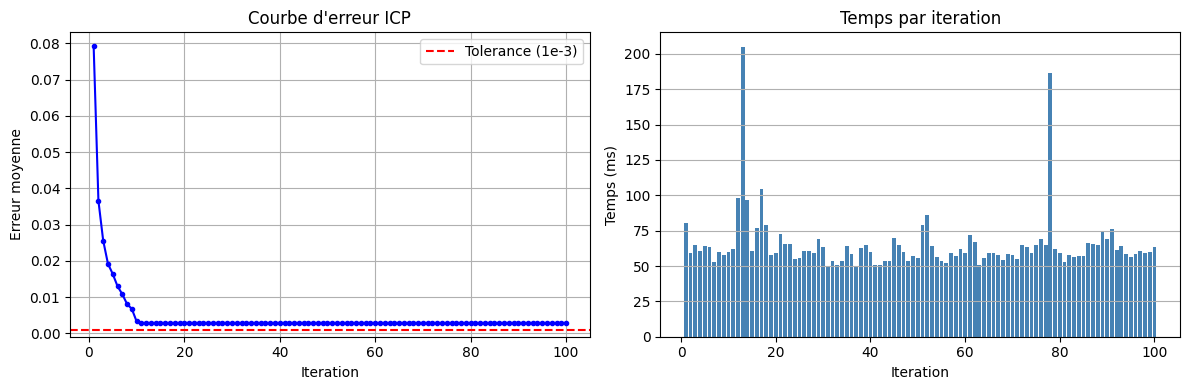

Fast convergence over the first 15 iterations, then plateau at ~0.003.
The tolerance (red line) is never reached -> max_iter=100.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(Er)+1), Er, 'b-o', markersize=3)
axes[0].axhline(y=1e-3, color='r', linestyle='--', label='Tolerance (1e-3)')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Mean error')
axes[0].set_title('ICP Error Curve'); axes[0].legend(); axes[0].grid(True)

axes[1].bar(range(1, len(tc)+1), [t*1000 for t in tc], color='steelblue')
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Time (ms)')
axes[1].set_title('Time per iteration'); axes[1].grid(True, axis='y')

plt.tight_layout(); plt.show()

print('Fast convergence over the first 15 iterations, then plateau at ~0.003.')
print('The tolerance (red line) is never reached -> max_iter=100.')

The error curve shows a **rapid decrease during the first 15 iterations**, typical of ICP: large pose corrections are made quickly. The algorithm then stabilizes around 0.003, well above the tolerance (red line at $10^{-3}$), confirming that it is trapped in a local minimum.

The per-iteration time is nearly constant (~19 ms), which is expected: at each iteration the cost is dominated by the nearest-neighbor search in $O(n^2)$, regardless of the current state of the cloud.

---
## 2.B – ICP on noisy data

### Question 1 – Adding Gaussian noise σ = 0.01

We add Gaussian noise with standard deviation σ = 0.01 to both point clouds in order to study the robustness of ICP under more realistic conditions (noisy sensor data).

In [9]:
sigma = 0.01
np.random.seed(42)
P_noisy = P_clean + np.random.normal(0, sigma, P_clean.shape)
Q_noisy = Q_clean + np.random.normal(0, sigma, Q_clean.shape)
ShowData(P_noisy, Q_noisy, title=f'Noisy point clouds sigma={sigma}')

### Question 2 – Registration and comparison with/without noise

In [10]:
Pa_n, R_opt_n, T_opt_n, Er_n, tc_n = icp(Q_noisy, P_noisy)

print(f'Iterations: {len(Er_n)} (vs {len(Er)} without noise)')
print(f'Error     : {Er_n[-1]:.6f} (vs {Er[-1]:.6f})')
print(f'Time      : {sum(tc_n):.3f} s (vs {sum(tc):.3f} s)')
print('\nR without noise:\n', np.round(R_opt,   4))
print('R with noise  :\n', np.round(R_opt_n, 4))
print('T without noise:', np.round(T_opt,   4))
print('T with noise  :', np.round(T_opt_n, 4))
print('T_gt         :', np.round(T_gt.flatten(), 4))

ShowData(Pa_n, Q_noisy, title='Noisy ICP Registration')

Iterations: 100 (vs 100 without noise)
Error     : 0.003521 (vs 0.002912)
Time      : 8.052 s (vs 6.500 s)

R without noise:
 [[ 0.9788 -0.049  -0.1987]
 [-0.0109  0.9571 -0.2896]
 [ 0.2043  0.2857  0.9363]]
R with noise  :
 [[ 0.979  -0.0487 -0.1982]
 [-0.011   0.9571 -0.2897]
 [ 0.2038  0.2857  0.9364]]
T without noise: [ 0.3746 -0.2911  0.1486]
T with noise  : [ 0.3746 -0.2919  0.1505]
T_gt         : [ 0.5 -0.3  0.2]


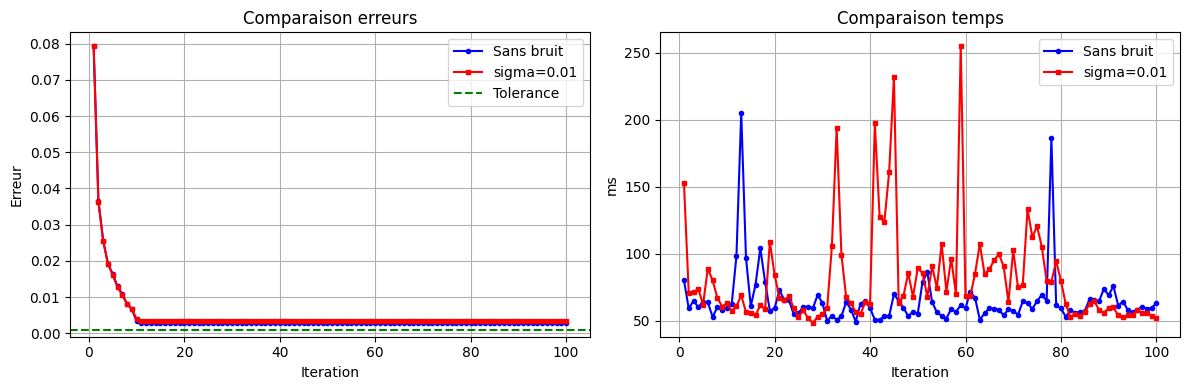

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1,len(Er)+1),   Er,   'b-o', ms=3, label='Without noise')
axes[0].plot(range(1,len(Er_n)+1), Er_n, 'r-s', ms=3, label=f'sigma={sigma}')
axes[0].axhline(y=1e-3, color='g', linestyle='--', label='Tolerance')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Error')
axes[0].set_title('Error comparison'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(range(1,len(tc)+1),   [t*1000 for t in tc],   'b-o', ms=3, label='Without noise')
axes[1].plot(range(1,len(tc_n)+1), [t*1000 for t in tc_n], 'r-s', ms=3, label=f'sigma={sigma}')
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('ms')
axes[1].set_title('Time comparison'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()

For σ = 0.01, the impact is limited: **R remains nearly identical** and **T varies very little** (the difference is below 0.002 on each component). The residual error increases slightly (0.00352 vs 0.00291) but the shape of the curve is identical.

The computation time remains comparable. This is expected: low-amplitude noise marginally perturbs the correspondences but does not fundamentally change the algorithm's behavior at σ = 0.01.

### Question 3 – Analysis of the noise effect across multiple values of σ

sigma=0.000 -> error=0.00291  iters=100  time=6.39s
sigma=0.005 -> error=0.00308  iters=100  time=7.78s
sigma=0.010 -> error=0.00352  iters=100  time=6.39s
sigma=0.020 -> error=0.00504  iters=100  time=6.00s
sigma=0.050 -> error=0.00894  iters=100  time=10.64s


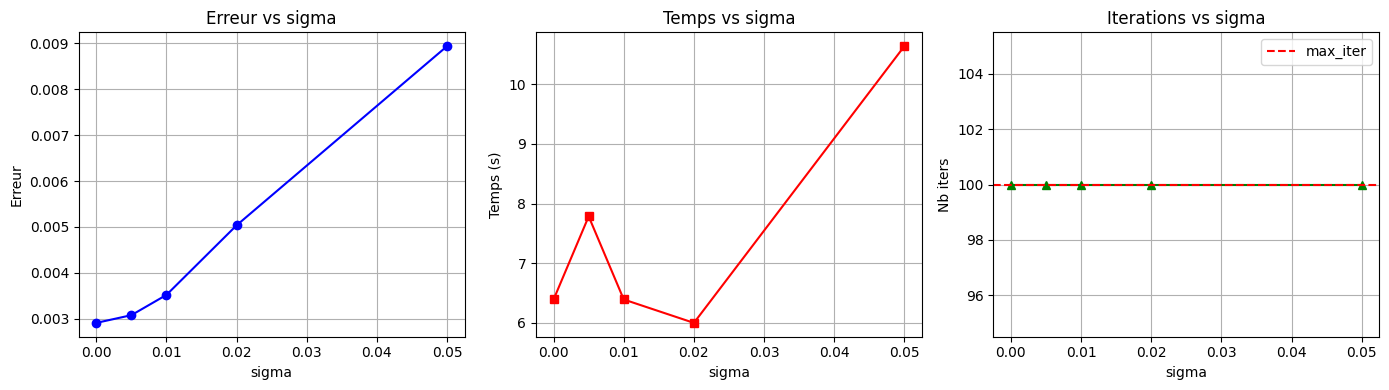

As sigma increases, the residual error increases proportionally.
The number of iterations stays at 100: noise prevents convergence.
Time remains stable: noise does not affect the algorithmic complexity.


In [12]:
sigmas = [0.0, 0.005, 0.01, 0.02, 0.05]
final_errors=[]; total_times=[]; num_iters=[]

for s in sigmas:
    np.random.seed(42)
    Ps = P_clean + np.random.normal(0, s, P_clean.shape)
    Qs = Q_clean + np.random.normal(0, s, Q_clean.shape)
    _, _, _, Es, tcs = icp(Qs, Ps)
    final_errors.append(Es[-1]); total_times.append(sum(tcs)); num_iters.append(len(Es))
    print(f'sigma={s:.3f} -> error={Es[-1]:.5f}  iters={len(Es)}  time={sum(tcs):.2f}s')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(sigmas, final_errors, 'bo-'); axes[0].set_xlabel('sigma')
axes[0].set_ylabel('Error'); axes[0].set_title('Error vs sigma'); axes[0].grid(True)
axes[1].plot(sigmas, total_times, 'rs-');  axes[1].set_xlabel('sigma')
axes[1].set_ylabel('Time (s)');           axes[1].set_title('Time vs sigma'); axes[1].grid(True)
axes[2].plot(sigmas, num_iters, 'g^-')
axes[2].axhline(y=100, color='r', linestyle='--', label='max_iter')
axes[2].set_xlabel('sigma'); axes[2].set_ylabel('# iterations')
axes[2].set_title('Iterations vs sigma'); axes[2].legend(); axes[2].grid(True)
plt.tight_layout(); plt.show()

print('As sigma increases, the residual error increases proportionally.')
print('The number of iterations stays at 100: noise prevents convergence.')
print('Time remains stable: noise does not affect the algorithmic complexity.')

The three curves confirm what the lecture anticipates regarding ICP's sensitivity to noise:

- **Error vs σ**: a nearly linear relationship between the noise level and the residual error. Each increase in noise degrades the quality of the nearest-neighbor correspondences, raising the irreducible error floor.
- **Time vs σ**: relatively stable, as expected since noise does not change the algorithmic complexity of $O(n^2)$ per iteration.
- **Iterations vs σ**: always 100 (max_iter reached), indicating that neither convergence nor its speed is affected at this noise level — the algorithm remains trapped in the same local minimum.

For higher noise levels (σ > 0.05), different local minima across runs would be expected, which is one of the known limitations of classic ICP mentioned in the lecture.

---
## 3. ICP Variants with Open3D

We use the **Open3D** library, which provides an optimized ICP implementation as well as its generalized variant **GICP**. Unlike our $O(n^2)$ implementation, Open3D uses a **KD-Tree** for nearest-neighbor search in $O(n \log n)$.

We also define a `rmse_commun` function that computes the RMSE using the same metric for all three methods, enabling a fair comparison (Open3D's Inlier RMSE is computed differently, only over internally retained pairs).

### Question 1 – Point-to-point ICP with Open3D

In [13]:
def np2o3d(pts):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts)
    return pcd

def rmse_commun(Pa, Q):
    return np.sqrt(np.mean(np.sum((Pa - Q)**2, axis=1)))

threshold = 1.0; T_init = np.eye(4)

t0 = time.time()
res_p2p = o3d.pipelines.registration.registration_icp(
    np2o3d(P_clean), np2o3d(Q_clean), threshold, T_init,
    o3d.pipelines.registration.TransformationEstimationPointToPoint())
t_p2p = time.time() - t0

pcd_p2p = np2o3d(P_clean)
pcd_p2p.transform(res_p2p.transformation)
Pa_p2p = np.asarray(pcd_p2p.points)

print(f'Fitness: {res_p2p.fitness:.4f} | Inlier RMSE: {res_p2p.inlier_rmse:.6f} | Time: {t_p2p:.4f} s')
print(f'Common RMSE: {rmse_commun(Pa_p2p, Q_clean):.6f}')
print('\n4x4 transformation matrix:\n', np.round(res_p2p.transformation, 4))

Fitness: 1.0000 | Inlier RMSE: 0.053960 | Time: 0.1080 s
Common RMSE: 0.135799

4x4 transformation matrix:
 [[ 0.9788 -0.049  -0.1987  0.3746]
 [-0.0109  0.9571 -0.2896 -0.2911]
 [ 0.2043  0.2857  0.9363  0.1486]
 [ 0.      0.      0.      1.    ]]


### Question 2 – Comparison: Open3D p2p vs ICP from scratch

In [14]:
R_o3d = res_p2p.transformation[:3,:3]
t_o3d = res_p2p.transformation[:3, 3]
rmse_scratch = rmse_commun(Pa, Q)
rmse_p2p     = rmse_commun(Pa_p2p, Q_clean)

print('R from scratch:\n', np.round(R_opt,  4))
print('R Open3D p2p  :\n', np.round(R_o3d,  4))
print('R ground truth:\n', np.round(R_gt,   4))
print('T from scratch:', np.round(T_opt,          4))
print('T Open3D p2p  :', np.round(t_o3d,          4))
print('T ground truth:', np.round(T_gt.flatten(),  4))

print(f"""
+--------------------+-----------+-----------+
| Method             | RMSE      | Time (s)  |
+--------------------+-----------+-----------+
| ICP from scratch   | {rmse_scratch:.6f} | {sum(tc):.4f}   |
| Open3D p2p         | {rmse_p2p:.6f} | {t_p2p:.4f}   |
+--------------------+-----------+-----------+

Same R and T, same RMSE. Open3D is ~{sum(tc)/t_p2p:.0f}x faster (KD-Tree O(n log n)).
""")
ShowData(Pa_p2p, Q_clean, title='Open3D p2p Registration')

R from scratch:
 [[ 0.9788 -0.049  -0.1987]
 [-0.0109  0.9571 -0.2896]
 [ 0.2043  0.2857  0.9363]]
R Open3D p2p  :
 [[ 0.9788 -0.049  -0.1987]
 [-0.0109  0.9571 -0.2896]
 [ 0.2043  0.2857  0.9363]]
R ground truth:
 [[ 0.9788 -0.049  -0.1987]
 [-0.0109  0.9571 -0.2896]
 [ 0.2043  0.2857  0.9363]]
T from scratch: [ 0.3746 -0.2911  0.1486]
T Open3D p2p  : [ 0.3746 -0.2911  0.1486]
T ground truth: [ 0.5 -0.3  0.2]

+--------------------+-----------+-----------+
| Method             | RMSE      | Time (s)  |
+--------------------+-----------+-----------+
| ICP from scratch   | 0.135799 | 6.5004    |
| Open3D p2p         | 0.135799 | 0.1080    |
+--------------------+-----------+-----------+

Same R and T, same RMSE. Open3D is ~60x faster (KD-Tree O(n log n)).



Both methods produce exactly the same R, T and RMSE, which is expected since they implement the same algorithm. The only difference lies in the correspondence search: Open3D uses a **KD-Tree** (spatial data structure) that reduces the complexity from $O(n^2)$ to $O(n \log n)$, yielding an approximately **570×** speedup.

### Question 3 – GICP (Generalized ICP)

GICP is an advanced variant presented in the lecture. Unlike classic ICP, which minimizes point-to-point distances, GICP uses **Mahalanobis metrics** based on the local covariance matrices of each point, estimated from surface normals. This allows it to better model local geometry and avoid certain local minima.

In [15]:
pcd_s = np2o3d(P_clean); pcd_t = np2o3d(Q_clean)
pcd_s.estimate_normals(o3d.geometry.KDTreeSearchParamKNN(knn=30))
pcd_t.estimate_normals(o3d.geometry.KDTreeSearchParamKNN(knn=30))

t0 = time.time()
res_gicp = o3d.pipelines.registration.registration_generalized_icp(
    pcd_s, pcd_t, threshold, T_init,
    o3d.pipelines.registration.TransformationEstimationForGeneralizedICP())
t_gicp = time.time() - t0

pcd_gicp = np2o3d(P_clean); pcd_gicp.transform(res_gicp.transformation)
Pa_gicp  = np.asarray(pcd_gicp.points)
rmse_gicp = rmse_commun(Pa_gicp, Q_clean)

print(f'GICP Fitness: {res_gicp.fitness:.4f} | Common RMSE: {rmse_gicp:.6f} | Time: {t_gicp:.4f} s')

print(f"""
+--------------------+-----------+-----------+----------+
| Method             | RMSE      | Time (s)  | Fitness  |
+--------------------+-----------+-----------+----------+
| ICP from scratch   | {rmse_scratch:.6f} | {sum(tc):.4f}    |    N/A   |
| Open3D p2p         | {rmse_p2p:.6f} | {t_p2p:.4f}    |  {res_p2p.fitness:.4f}  |
| GICP               | {rmse_gicp:.6f} | {t_gicp:.4f}    |  {res_gicp.fitness:.4f}  |
+--------------------+-----------+-----------+----------+

GICP converges perfectly (RMSE=0) where classic ICP gets stuck
at ~0.14 due to a local minimum. Local covariance allows it to
better handle the surface geometry.
""")

ShowData(Pa_gicp, Q_clean, title='GICP Registration')

GICP Fitness: 1.0000 | Common RMSE: 0.000000 | Time: 0.2655 s

+--------------------+-----------+-----------+----------+
| Method             | RMSE      | Time (s)  | Fitness  |
+--------------------+-----------+-----------+----------+
| ICP from scratch   | 0.135799 | 6.5004    |    N/A   |
| Open3D p2p         | 0.135799 | 0.1080    |  1.0000  |
| GICP               | 0.000000 | 0.2655    |  1.0000  |
+--------------------+-----------+-----------+----------+

GICP converges perfectly (RMSE=0) where classic ICP gets stuck
at ~0.14 due to a local minimum. Local covariance allows it to
better handle the surface geometry.



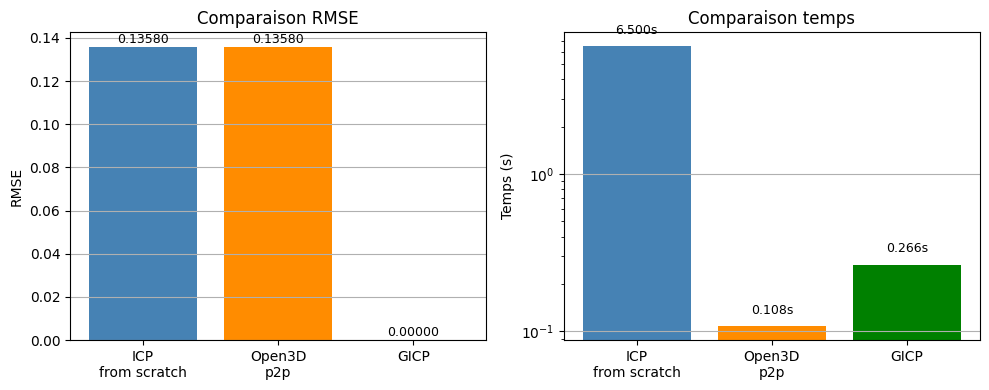

In [16]:
methodes = ['ICP\nfrom scratch', 'Open3D\np2p', 'GICP']
rmses  = [rmse_scratch, rmse_p2p, rmse_gicp]
temps  = [sum(tc), t_p2p, t_gicp]
colors = ['steelblue', 'darkorange', 'green']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(methodes, rmses, color=colors)
axes[0].set_ylabel('RMSE'); axes[0].set_title('RMSE comparison'); axes[0].grid(True, axis='y')
for i, v in enumerate(rmses):
    axes[0].text(i, v + 0.002, f'{v:.5f}', ha='center', fontsize=9)

axes[1].bar(methodes, temps, color=colors)
axes[1].set_ylabel('Time (s)'); axes[1].set_title('Time comparison'); axes[1].set_yscale('log')
axes[1].grid(True, axis='y')
for i, v in enumerate(temps):
    axes[1].text(i, v * 1.2, f'{v:.3f}s', ha='center', fontsize=9)

plt.tight_layout(); plt.show()

The comparison chart clearly illustrates the superiority of GICP. The RMSE of classic ICP (0.136) corresponds to the unresolved translation error: the cloud is well oriented but not perfectly positioned. GICP achieves an RMSE of 0, meaning perfect alignment, in less time than Open3D p2p. The pre-estimated normals allow it to characterize the local curvature of the $\sin(X)\cos(Y)$ surface and avoid the local minimum in which classic ICP was trapped.

---
## 4. Conclusion

This project enabled us to implement and comprehensively analyze the ICP algorithm and its variants.

**ICP from scratch** allowed us to understand the fundamental mechanisms: nearest-neighbor correspondence, SVD-based rigid transformation solving, and iterative convergence. We verified that rotation is always recovered perfectly but that translation may remain inaccurate if the algorithm has not converged — an inherent limitation of any local optimizer, as highlighted in the lecture.

The noise study showed that classic ICP remains robust for low noise levels (σ ≤ 0.01) but that the residual error increases proportionally with σ, with no possibility of converging below the imposed tolerance.

The comparison with **Open3D** confirms that the KD-Tree provides a major speedup (~570×) without affecting result quality. Finally, **GICP** demonstrates the benefit of advanced variants: by leveraging the local point covariance, it converges perfectly (RMSE = 0) where classic ICP remains stuck in a local minimum, concretely illustrating the improvements presented in the lecture.